# Bitter vs Sweet Compound Classifier

---

In this notebook we will build a machine learning model that can **predict whether a molecule tastes bitter or sweet**, based on its chemical structure.

---

> **Required libraries:** `rdkit`, `scikit-learn`, `pandas`, `numpy`, `matplotlib`
> Install with: `pip install rdkit scikit-learn pandas numpy matplotlib`

## Some useful links:

**Numpy**: https://numpy.org/doc/stable/user/quickstart.html

**Pandas**: https://pandas.pydata.org/docs/getting_started/intro_tutorials/

**RDKit**: https://www.rdkit.org/docs/GettingStartedInPython.html

**Scikit-learn**: https://scikit-learn.org/stable/getting_started.html

**Matplotlib**: https://matplotlib.org/stable/users/explain/quick_start.html

In [121]:
#!pip install rdkit scikit-learn pandas numpy matplotlib --yes

## Step 1 — Import the Libraries We Need

We first import all the Python libraries we will use.

| Library | What it does |
|---|---|
| `pandas` | Handles tables of data (like Excel in Python) |
| `numpy` | Handles numbers and arrays efficiently |
| `matplotlib` | Makes plots and charts |
| `rdkit` | Reads and processes chemical molecules |
| `sklearn` | Provides machine learning algorithms |

In [122]:
# --- Standard Python libraries ---
import numpy as np               # arrays and math
import pandas as pd              # tables (DataFrames)
import matplotlib.pyplot as plt  # plotting
import pickle                    # saving/loading Python objects to disk

# --- Chemistry library: RDKit ---
from rdkit import Chem                                              # parse molecules
from rdkit.Chem import Descriptors                                  # compute MW, logP, etc.
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator    # fingerprints
from rdkit.Chem.SaltRemover import SaltRemover                      # remove salts if present in the SMILES

# --- Machine learning: scikit-learn ---
from sklearn.ensemble import RandomForestClassifier                     # The Machine Learning Algorithm we are going to use
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    auc,
    roc_curve,
    ConfusionMatrixDisplay,
)

print("All imports successful!")

All imports successful!


## Step 2 — Configuration

Here we set the main **parameters** for our experiment. You can change values here without touching the rest of the code.

**What is a SMILES string?**  
Molecules are complex 3D objects, but chemists have invented a text notation called **SMILES** (Simplified Molecular Input Line Entry System) to represent them as plain text.  
For example, caffeine (a bitter compound) is: `CN1C=NC2=C1C(=O)N(C(=O)N2C)C`

**What is a Morgan Fingerprint?**  
A Morgan fingerprint is a way to convert a molecule into a **list of 1s and 0s** (a bit vector). Each bit represents whether a certain chemical feature is present. This lets our ML model "read" the molecule.

In [123]:
# --- File paths ---
DATA_PATH      = 'bittersweet.csv'        # main dataset
SAVE_PATH      = 'bittersweet_model.pkl'  # where to save the trained model

# --- Morgan fingerprint settings ---
MORGAN_RADIUS = 2     # how far around each atom to look (2 = standard)
MORGAN_NBITS  = 1024  # length of the fingerprint bit vector

# --- Filtering thresholds (Step 4 will use these) ---
# EXERCISE: Try changing these values and see how the dataset size changes!
MAX_MW   = None   # Maximum Molecular Weight in Da. None = no filter
MIN_LOGP = None   # Maximum logP (lipophilicity).   None = no filter

print("Configuration set.")
print(f"Filtering: MW ≤ {MAX_MW}, logP > {MIN_LOGP}  (None = no filter applied)")

Configuration set.
Filtering: MW ≤ None, logP > None  (None = no filter applied)


## Step 3 — Load the Dataset

We load our data from a CSV file. Each row is one compound with:
- `SMILES` — the text representation of the molecule
- `Taste`  — the label: **bitter** or **sweet**

We also **clean** the labels (make them all lowercase and remove spaces) to avoid mismatches.

In [124]:
# Load the CSV into a DataFrame
df = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
print(f"Column names: {df.columns.tolist()}")

# Preview the first 5 rows
df.head()

Loaded 3378 rows and 3 columns.
Column names: ['SMILES', 'Name', 'Taste']


,SMILES,Name,Taste
0,COC1=CC2=C(C=CN=C2C=C1)C(C3CC4CCN3CC4C=C)O.OS(...,(5-ethenyl-1-azabicyclo[2.2.2]octan-2-yl)-(6-m...,bitter
1,COC1=CC2=C(C=CN=C2C=C1)C(C3CC4CC[NH+]3CC4C=C)O,"(R)-[(2S,4R,5R)-5-ethenyl-1-azoniabicyclo[2.2....",bitter
2,CC(C)CC(=O)C1=C(C(C(=O)C(C1=O)CC=C(C)C)(CC=C(C...,"5,6-dihydroxy-4-(3-methylbutanoyl)-2,6-bis(3-m...",bitter
3,COC1=CC2=C(C=CN=C2C=C1)C(C3CC4CCN3CC4C=C)O.COC...,(5-ethenyl-1-azabicyclo[2.2.2]octan-2-yl)-(6-m...,bitter
4,C1=CC=C(C=C1)C=O,benzaldehyde,bitter


In [125]:
# Clean up the Taste column: strip spaces, make lowercase
df['Taste'] = df['Taste'].str.strip().str.lower()

# Count how many bitter vs sweet compounds we have
n_bitter = (df['Taste'] == 'bitter').sum()
n_sweet  = (df['Taste'] == 'sweet').sum()

print(f"Total compounds: {len(df)}")
print(f"  Bitter: {n_bitter}")
print(f"  Sweet : {n_sweet}")

Total compounds: 3378
  Bitter: 2142
  Sweet : 1236


## Step 4 — Clean & Filter Molecules by Physical Properties

**4.1**
Online databases are often filled with molecules represented as SMILES, but these SMILES could still contain also salts or represent mixtures of molecules.

> The ChEMBL Structure Pipeline is one of the most robust publicly available workflows for SMILES standardization because it enforces chemically consistent rules, handles edge cases, and aligns with how major cheminformatics databases curate structures. It is available at https://github.com/chembl/ChEMBL_Structure_Pipeline.

For simplicity, we will remove all salts from the SMILES strings using RDKit’s SaltRemover() function and exclude any entries that represent mixtures rather than single molecules.

**4.2**
Sometimes we want to remove molecules that are too large or too hydrophilic or hydrophobic, based on the biological background.

**Key properties:**
- **Molecular Weight (MW):** How heavy the molecule is (in Daltons).
- **logP:** A measure of how much the molecule prefers oil vs water. High logP = more "oily", low logP = more "water-soluble".

You can set `MAX_MW` and `MIN_LOGP` in the **Configuration cell** (Step 2) to activate filtering.
Set them to `None` to skip the filter for the first training iteration.

In [126]:
def compute_mw_logp(smiles):
    """Compute Molecular Weight and logP for a SMILES string.
    Returns (None, None) if the molecule cannot be parsed.
    """
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None, None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    return mw, logp

remover = SaltRemover()

def remove_salts(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    stripped = remover.StripMol(mol)
    return Chem.MolToSmiles(stripped)

df['SMILES'] = df['SMILES'].apply(remove_salts)

# Remove mixtures
df = df[~df['SMILES'].str.contains(r'\.', regex=True)].reset_index(drop=True)

# Compute MW and logP for every molecule in the dataset
print("Computing MW and logP for all molecules (this may take a moment)...")
mw_list   = []
logp_list = []

for smi in df['SMILES']:
    mw, logp = compute_mw_logp(smi)
    mw_list.append(mw)
    logp_list.append(logp)

df['MW']   = mw_list
df['logP'] = logp_list

print(f"MW   — min: {df['MW'].min():.1f}, max: {df['MW'].max():.1f}")
print(f"logP — min: {df['logP'].min():.2f}, max: {df['logP'].max():.2f}")

[10:59:18] WARNING: not removing hydrogen atom without neighbors
[10:59:19] WARNING: not removing hydrogen atom without neighbors


Computing MW and logP for all molecules (this may take a moment)...
MW   — min: 0.0, max: 4280.0
logP — min: -16.11, max: 10.27


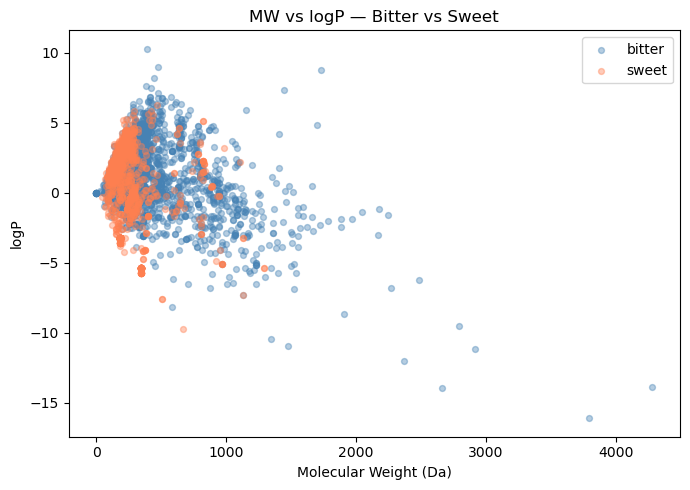

In [127]:
# Quick scatter plot: MW vs logP, coloured by taste
palette = {'bitter': 'steelblue', 'sweet': 'coral'}

fig, ax = plt.subplots(figsize=(7, 5))
for taste, group in df.groupby('Taste'):
    ax.scatter(group['MW'], group['logP'],c=palette[taste], alpha=0.4, s=18, label=taste)

# Draw threshold lines if filters are active
if MAX_MW is not None:
    ax.axvline(MAX_MW, color='black', linestyle='--', linewidth=1.2, label=f'MW cutoff = {MAX_MW}')
if MIN_LOGP is not None:
    ax.axhline(MIN_LOGP, color='gray', linestyle='--', linewidth=1.2, label=f'logP cutoff = {MIN_LOGP}')

ax.set_xlabel('Molecular Weight (Da)')
ax.set_ylabel('logP')
ax.set_title('MW vs logP — Bitter vs Sweet')
ax.legend()
plt.tight_layout()
plt.show()

In [128]:
# Apply the filters from the Configuration cell
# We only filter if the threshold is set (not None)

n_before = len(df)

if MAX_MW is not None:
    df = df[df['MW'] <= MAX_MW]
    print(f"After MW ≤ {MAX_MW} filter : {len(df)} molecules remaining  (removed {n_before - len(df)})")
    n_before = len(df)

if MIN_LOGP is not None:
    df = df[df['logP'] > MIN_LOGP]
    print(f"After logP > {MIN_LOGP} filter: {len(df)} molecules remaining  (removed {n_before - len(df)})")

df = df.reset_index(drop=True)

print(f"\nFinal dataset size: {len(df)} molecules")
print(f"  Bitter: {(df['Taste']=='bitter').sum()}")
print(f"  Sweet : {(df['Taste']=='sweet').sum()}")


Final dataset size: 3332 molecules
  Bitter: 2110
  Sweet : 1222


## Step 5 — Convert Molecules to Numbers (Morgan Fingerprints)

Machine learning models only understand **numbers**, not chemical structures. We need a way to encode each molecule as a fixed-length list of numbers.

**Morgan fingerprints** work by:
1. Looking at each atom in the molecule
2. Examining the chemical environment within a certain radius around that atom
3. Hashing that environment to a bit position in a vector of length `n_bits`
4. Setting that bit to `1` if the feature is present, `0` otherwise

The result: every molecule becomes a list of `n_bits` zeros and ones.

We also handle **bad SMILES** — if a string cannot be parsed, we skip it.

In [129]:
def smiles_to_morgan(smiles, generator):
    """Convert a SMILES string to a Morgan fingerprint array.
    Returns None if the molecule cannot be read.
    """
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return generator.GetFingerprintAsNumPy(mol)


def build_morgan_features(smiles_list, radius=2, n_bits=1024):
    """Build a feature matrix from a list of SMILES strings.
    
    Returns:
        X          - a 2D array of shape (n_molecules, n_bits)
        valid_mask - a list of True/False for each molecule
                     (False = could not be parsed)
    """
    # Create the fingerprint generator once — it is then reused for each molecule
    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)
    
    fingerprints = []   # will collect one array per molecule
    valid_mask   = []   # will track which SMILES were valid

    for smi in smiles_list:
        fp = smiles_to_morgan(smi, generator)
        if fp is not None:
            fingerprints.append(fp)
            valid_mask.append(True)
        else:
            # Use a zero vector as a placeholder so the array stays the same length
            fingerprints.append(np.zeros(n_bits, dtype=np.uint8))
            valid_mask.append(False)
    
    # Stack the list of 1D arrays into one big 2D matrix
    X = np.array(fingerprints, dtype=np.float32)
    return X, valid_mask


# Build features for our dataset
print("Computing Morgan fingerprints...")
X, valid_mask = build_morgan_features(df['SMILES'], radius=MORGAN_RADIUS, n_bits=MORGAN_NBITS)

n_invalid = sum(1 for v in valid_mask if not v)
print(f"Feature matrix shape : {X.shape}  (molecules × bits)")
print(f"Invalid SMILES skipped: {n_invalid}")

Computing Morgan fingerprints...
Feature matrix shape : (3332, 1024)  (molecules × bits)
Invalid SMILES skipped: 0


In [130]:
# Create the target variable y
# We encode: bitter = 1, sweet = 0
y = (df['Taste'] == 'bitter').astype(int).values

print(f"Target array y: {y.shape}")
print(f"  1 (bitter): {y.sum()}")
print(f"  0 (sweet) : {(y == 0).sum()}")

Target array y: (3332,)
  1 (bitter): 2110
  0 (sweet) : 1222


## Step 6 — Split Data into Training and Test Sets

**Never evaluate a model on data it was trained on!**

We split our data:
- **80% training set** — the model learns from this
- **20% test set** — we evaluate performance on this (model never sees it during training)

We use `stratify=y` to make sure the bitter/sweet ratio is preserved in both splits.

In [131]:
# Split data: 80% train, 20% test
# random_state=42 makes the split reproducible (same split every time you run this)
# stratify=y keeps the class ratio the same in both splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape[0]} molecules")
print(f"Test set     : {X_test.shape[0]} molecules")
print()
print(f"Train — bitter: {y_train.sum()}, sweet: {(y_train==0).sum()}")
print(f"Test  — bitter: {y_test.sum()},  sweet: {(y_test==0).sum()}")

Training set : 2665 molecules
Test set     : 667 molecules

Train — bitter: 1688, sweet: 977
Test  — bitter: 422,  sweet: 245


## Step 7 — Train a Random Forest Classifier

A **Random Forest** is an ensemble of many decision trees. Each tree makes its own prediction, and the forest combines them by majority vote.

Key settings we use:
| Parameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 200 | Number of trees in the forest |
| `max_features` | `"sqrt"` | Each tree only sees √(n_features) random features — prevents overfitting |
| `class_weight` | `"balanced"` | Automatically corrects for class imbalance (more bitter than sweet) |
| `random_state` | 42 | Makes results reproducible |

In [132]:
# Create and train the Random Forest model
print("Training Random Forest...")

clf = RandomForestClassifier(
    n_estimators=200,        # 200 decision trees
    max_depth=None,          # let trees grow as deep as needed
    min_samples_split=2,     # split a node if it has at least 2 samples
    min_samples_leaf=1,      # each leaf must have at least 1 sample
    max_features='sqrt',     # use sqrt(n_features) at each split
    class_weight='balanced', # handle class imbalance automatically
    random_state=42,
    n_jobs=-1,               # use all CPU cores for speed
)

clf.fit(X_train, y_train)

print("Training complete!")

Training Random Forest...
Training complete!


## Step 8 — Evaluate on the Test Set

Now we measure how well our model performs on data it has **never seen**.

**Metrics explained:**
- **Precision:** Of all molecules predicted as bitter, what fraction is actually bitter?
- **Recall:** Of all actual bitter molecules, what fraction did we correctly identify?
- **F1-score:** The harmonic mean of precision and recall (balance between the two)
- **ROC-AUC:** Measures the model's ability to rank positives above negatives (1.0 = perfect, 0.5 = random)

In [133]:
# Make predictions on the test set
y_pred = clf.predict(X_test)              # predicted class labels (0 or 1)
y_prob = clf.predict_proba(X_test)[:, 1]  # predicted probability of being bitter

print('=' * 50)
print('Test-Set Performance Report')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['sweet (0)', 'bitter (1)']))
print(f"ROC-AUC score: {roc_auc_score(y_test, y_prob):.4f}")

Test-Set Performance Report
              precision    recall  f1-score   support

   sweet (0)       0.92      0.88      0.90       245
  bitter (1)       0.93      0.96      0.94       422

    accuracy                           0.93       667
   macro avg       0.93      0.92      0.92       667
weighted avg       0.93      0.93      0.93       667

ROC-AUC score: 0.9731


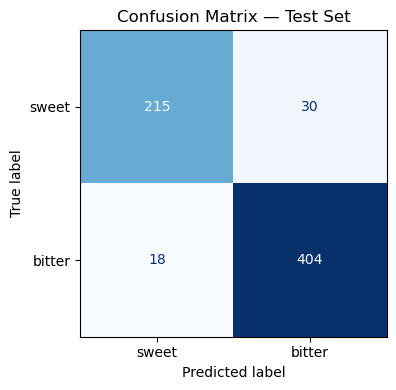

Correctly predicted sweet  (True Negatives) : 215
Incorrectly called bitter  (False Positives): 30
Missed bitter compounds    (False Negatives): 18
Correctly predicted bitter (True Positives) : 404


In [134]:
# Plot the Confusion Matrix
# Rows = actual class, Columns = predicted class
# Diagonal = correct predictions

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['sweet', 'bitter'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

# Simple explanation
tn, fp, fn, tp = cm.ravel()
print(f"Correctly predicted sweet  (True Negatives) : {tn}")
print(f"Incorrectly called bitter  (False Positives): {fp}")
print(f"Missed bitter compounds    (False Negatives): {fn}")
print(f"Correctly predicted bitter (True Positives) : {tp}")

## Step 9 — Stratified 5-Fold Cross-Validation with Best Model Saving

A single train/test split can be **lucky or unlucky** depending on which molecules end up in each set. **Cross-validation** gives a more reliable estimate by repeating the process 5 times.

**How 5-fold CV works:**
1. Divide the data into 5 equally-sized "folds"
2. In each round, use 4 folds for training and 1 fold for testing
3. Repeat 5 times so every fold is used as the test set exactly once
4. Average the 5 scores to get a robust performance estimate

We also **save the best fold's model** in a variable so we can use it later!

In [135]:
import copy
print("Running Stratified 5-Fold Cross-Validation...")
print("(Each fold trains a fresh model)\n")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_auc        = 0.0
best_fold       = -1
best_fold_model = None

fold_scores = []   # AUCs for each fold

fprs = []          # list of FPR arrays
tprs = []          # list of TPR arrays
aucs = []          # list of AUC values

for fold_num, (train_idx, val_idx) in enumerate(kf.split(X, y), start=1):

    X_fold_train = X[train_idx]
    y_fold_train = y[train_idx]
    X_fold_val   = X[val_idx]
    y_fold_val   = y[val_idx]

    fold_clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )

    fold_clf.fit(X_fold_train, y_fold_train)

    # Predict probabilities
    fold_probs = fold_clf.predict_proba(X_fold_val)[:, 1]

    # Compute AUC
    fold_auc = roc_auc_score(y_fold_val, fold_probs)
    fold_scores.append(fold_auc)
    aucs.append(fold_auc)

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_fold_val, fold_probs)
    fprs.append(fpr)
    tprs.append(tpr)

    print(f"  Fold {fold_num}: ROC-AUC = {fold_auc:.4f}")

    # Track best fold
    if fold_auc > best_auc:
        best_auc        = fold_auc
        best_fold       = fold_num
        best_fold_model = copy.deepcopy(fold_clf)

# Summary
fold_scores_array = np.array(fold_scores)
print()
print(f"CV Results — Mean AUC: {fold_scores_array.mean():.4f} ± {fold_scores_array.std():.4f}")
print(f"Best fold  : Fold {best_fold} with AUC = {best_auc:.4f}")
print()
print("The best fold model is saved in the variable: best_fold_model")
print("ROC curve data stored in: fprs, tprs, aucs")

Running Stratified 5-Fold Cross-Validation...
(Each fold trains a fresh model)

  Fold 1: ROC-AUC = 0.9614
  Fold 2: ROC-AUC = 0.9640
  Fold 3: ROC-AUC = 0.9683
  Fold 4: ROC-AUC = 0.9653
  Fold 5: ROC-AUC = 0.9654

CV Results — Mean AUC: 0.9649 ± 0.0022
Best fold  : Fold 3 with AUC = 0.9683

The best fold model is saved in the variable: best_fold_model
ROC curve data stored in: fprs, tprs, aucs


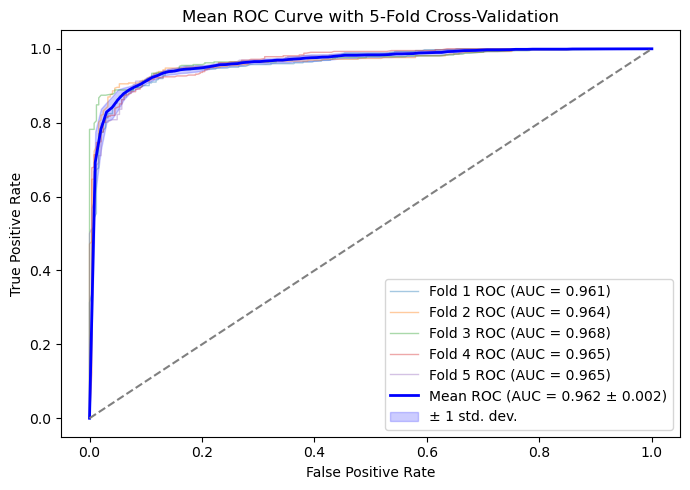

In [136]:
# Create a common FPR grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

interp_tprs = []
for fpr, tpr in zip(fprs, tprs):
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    interp_tprs.append(interp_tpr)

mean_tpr = np.mean(interp_tprs, axis=0)
std_tpr = np.std(interp_tprs, axis=0)

mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

# Plot each fold ROC
for i, (fpr, tpr, fold_auc) in enumerate(zip(fprs, tprs, aucs)):
    ax.plot(fpr, tpr, lw=1, alpha=0.4,
            label=f'Fold {i+1} ROC (AUC = {fold_auc:.3f})')

# Plot mean ROC
ax.plot(mean_fpr, mean_tpr, color='blue',
        label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
        lw=2)

# Plot std band
tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2,
                label='± 1 std. dev.')

# Chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.set_title('Mean ROC Curve with 5-Fold Cross-Validation')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 10 — Feature Importance: What Does the Model Look At?

Random Forests can tell us **which features (Morgan bits) were most useful** for making predictions. A high importance score means that bit helped the model a lot.

We plot the top 20 most important fingerprint bits below.

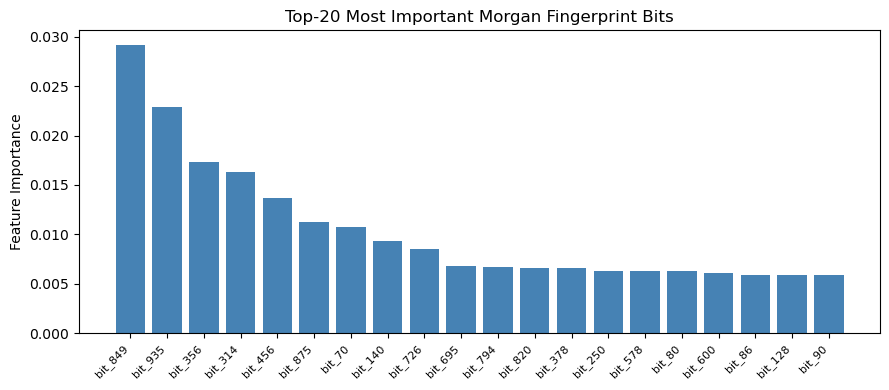

The x-axis shows Morgan bit indices.
Each bit corresponds to a specific chemical substructure pattern.


In [137]:
# Get feature importances from the trained model (clf from Step 7)
importances = clf.feature_importances_   # one value per bit

# argsort returns indices that would sort the array
# [::-1] reverses it so largest is first
# [:20] takes only the top 20
top_indices = np.argsort(importances)[::-1][:20]
top_names   = [f'bit_{i}' for i in top_indices]
top_values  = importances[top_indices]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(20), top_values, color='steelblue')
ax.set_xticks(range(20))
ax.set_xticklabels(top_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Feature Importance')
ax.set_title('Top-20 Most Important Morgan Fingerprint Bits')
plt.tight_layout()
plt.show()

print("The x-axis shows Morgan bit indices.")
print("Each bit corresponds to a specific chemical substructure pattern.")

## Additional Insight: Plotting the important Bits on the molecules

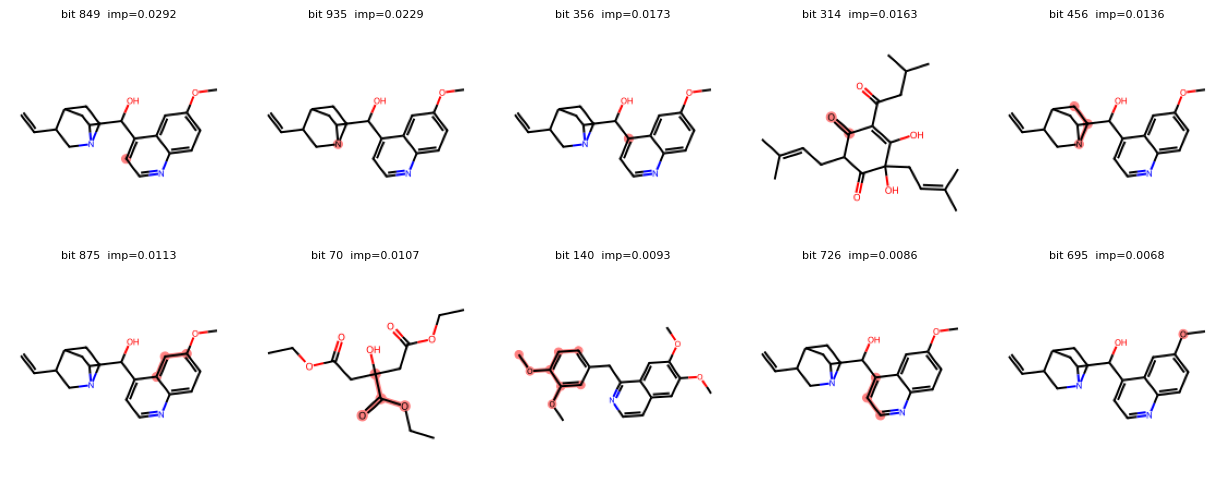

In [138]:
from rdkit.Chem.rdFingerprintGenerator import AdditionalOutput
from rdkit.Chem.Draw import rdMolDraw2D

results = []

for bit_idx in top_indices[:10]:
    for smiles in df['SMILES'].to_list():
        mol = Chem.MolFromSmiles(smiles)
        gen = GetMorganGenerator(radius=MORGAN_RADIUS, fpSize=MORGAN_NBITS)
        ao  = AdditionalOutput()
        ao.AllocateBitInfoMap()
        fp  = gen.GetFingerprint(mol, additionalOutput=ao)
        bit_info = ao.GetBitInfoMap()
        if int(bit_idx) in bit_info:
            results.append((mol, bit_idx, bit_info, smiles))  # ← add smiles
            break

imgs = []
legends = []

for mol, bit_idx, bit_info, smiles in results:
    atomId, radius = bit_info[int(bit_idx)][0]

    if radius == 0:
        highlight_atoms = [atomId]
        highlight_bonds = []
    else:
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atomId)
        highlight_atoms = set()
        for bond_idx in env:
            bond = mol.GetBondWithIdx(bond_idx)
            highlight_atoms.add(bond.GetBeginAtomIdx())
            highlight_atoms.add(bond.GetEndAtomIdx())
        highlight_atoms = list(highlight_atoms)
        highlight_bonds = list(env)

    drawer = rdMolDraw2D.MolDraw2DCairo(200, 200)
    drawer.drawOptions().addAtomIndices = False
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=highlight_atoms,
        highlightBonds=highlight_bonds,
    )
    drawer.FinishDrawing()

    from PIL import Image
    import io
    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    imgs.append(img)
    legends.append(f"bit {int(bit_idx)}  imp={clf.feature_importances_[bit_idx]:.4f}")

import math

ncols = 5
nrows = math.ceil(len(imgs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
axes = np.array(axes).flatten()

for ax, img, legend in zip(axes, imgs, legends):
    ax.imshow(img)
    ax.set_title(legend, fontsize=8)
    ax.axis('off')

for ax in axes[len(imgs):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 11 — Save the Trained Model

We can save the model to disk using `pickle`, so we don't have to retrain it every time we want to make predictions.

We save both:
- `clf` — the model trained on the full 80% training split
- `best_fold_model` — the best cross-validation fold model

In [139]:
# Save the best CV fold model
best_fold_save_path = SAVE_PATH.replace('.pkl', '_best_fold.pkl')
with open(best_fold_save_path, 'wb') as f:
    pickle.dump(best_fold_model, f)
print(f"Best fold model saved to: {best_fold_save_path}")

# --- How to load a saved model later ---
# with open(SAVE_PATH, 'rb') as f:
#     loaded_model = pickle.load(f)

Main model saved to: bittersweet_model.pkl
Best fold model saved to: bittersweet_model_best_fold.pkl


---

## You've Built a Bitter/Sweet taste Classifier!

---

### What can we do to improve on it?

1. **Change `MAX_MW` and `MAX_LOGP`** in Step 2 — how does filtering affect model performance?
2. **Increase `n_estimators`** from 200 to 500 and then 1000 — does accuracy improve?
3. **Change `MORGAN_RADIUS`** from 2 to 3 — longer radius = more structural context
4. **Try a different model** — replace `RandomForestClassifier` with `GradientBoostingClassifier` or `ExtraTreesClassifier`... have a look here for all the model algorithms available https://scikit-learn.org/stable/supervised_learning.html